<style>
table {
    font-size: 8px;
    width: 100%;
    table-layout: fixed;
}

th, td {
    word-wrap: break-word;
    overflow-wrap: break-word;
    text-align: center;
}
</style>
# Introduction

Dans ce Notebook, je travaille **uniquement** sur les données ab-initio de **Toczylowski**.

J'ai seulement récupéré les paramètres obtenus avec les "meilleurs" fit des méthodes curve_fit et least_squares, qui, vous le verrez sont quasi identiques en terme de résultats.

J'ai ajouté les paramètres donnés par Toczylowski dans sa thèse à titre de comparaison.

## Tableau des Erreurs pas méthode :
|    Méthode                         |          R²          |       RMSE (mEh)      |        MAE (mEh)       |
|------------------------------------|----------------------|-----------------------|------------------------|
| **Toczylowski**                    | $0.9973571231491378$ | $0.14053712510676145$ | $0.07967955352389043$  |
| **curve_fit + 'lm'**               | $0.9999998091291987$ | $0.00119432452372047$ | $0.00087006388462275$  |
| curve_fit + 'lm'  + sigma          | $0.9999910167165791$ | $0.00819351310342679$ | $0.00276581346507194$  |
| curve_fit + 'trf'                  | $0.9999997616897787$ | $0.00133451646592886$ | $0.00094146809737027$  |
| curve_fit + 'trf' + sigma          | $0.9999247424840818$ | $0.02371524093658603$ | $0.00688134668613111$  |
| least_squares                      | $0.9999997618394195$ | $0.00133409741213665$ | $0.00094175867130043$  |
| least_squares + 'jac'              | $0.9999998091292266$ | $0.00119432443657110$ | $0.00087005663911204$  |
| **least_squares + 'jac' + 'soft'** | $0.9999998091292273$ | $0.00119432443466397$ | $0.00087005338244569$  |
| least_squares + 'jac' + 'huber'    | $0.9999998091292276$ | $0.00119432443330507$ | $0.00087005649593775$  |

|    Méthode                         |          R²          |      RMSE (cm⁻¹)      |       MAE (cm⁻¹)      |
|------------------------------------|----------------------|-----------------------|-----------------------|
| **Toczylowski**                    | $0.9973571231491378$ | $30.844322096260684$  | $17.487605474609086$  |
| **curve_fit + 'lm'**               | $0.9999998091291987$ | $0.2621241445163892$  | $0.1909574902355770$  |
| curve_fit + 'lm'  + sigma          | $0.9999910167165791$ | $1.7982675553449088$  | $0.6070264446832262$  |
| curve_fit + 'trf'                  | $0.9999997616897787$ | $0.2928928987596549$  | $0.2066283907162378$  |
| curve_fit + 'trf' + sigma          | $0.9999247424840818$ | $5.204892897347624$   | $1.5102786155597213$  |
| least_squares                      | $0.9999997618394195$ | $0.2928009419314839$  | $0.2066921462514732$  |
| least_squares + 'jac'              | $0.9999998091292266$ | $0.2621241253934157$  | $0.1909559001545393$  |
| **least_squares + 'jac' + 'soft'** | $0.9999998091292273$ | $0.2621241249748908$  | $0.1909551855687354$  |
| least_squares + 'jac' + 'huber'    | $0.9999998091292276$ | $0.2621241246766935$  | $0.1909558687387600$  |


Les méthodes en **gras** sont celles pour lesquelles j'ai selectionné les paramètres pour ce Notebook


Rappel :

- R2 : sans unité, indique sur la tendance globale
- RMSE : Racine de l’erreur quadratique moyenne (ici en cm$^{−1}$), mise en valeur des erreurs importantes
- MAE : Erreur absolue moyenne (ici en cm$^{−1}$), mise en valeur de l’erreur moyenne

In [127]:
import numpy as np

import matplotlib.pyplot as plt
import numpy.lib.recfunctions as rfn
from  matplotlib.lines import Line2D

import Fonctions.Affichage
import Fonctions.Metriques
import Fonctions.Vopt

import importlib
importlib.reload(Fonctions.Affichage)
importlib.reload(Fonctions.Metriques)
importlib.reload(Fonctions.Vopt)

from Fonctions.Vopt import V_opt
from Fonctions.Affichage import plot_interactif, multi_plot_interactif
from Fonctions.Affichage import plot_Theta_fix_zoom, plot_Theta_fix_zoom_cmm1
from Fonctions.Affichage import plot_R_fix, plot_R_fix_cmm1, to_grid, erreur_rel_contour, erreur_rel_tricontour

# Import des données

In [2]:
# Tableau : Ar-HCN
Ar = np.genfromtxt("Data/Ar-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
E_mEh = np.asarray(Ar['Energy']) * 1e-3
# Ajout de la colonne en Eh
Ar = rfn.append_fields(Ar, names='Energy_mEh', data=E_mEh, usemask=False)
# Suppression de l'ancienne colonne
Ar = rfn.drop_fields(Ar,'Energy',usemask=False)

# Parametres donnés par Toczylowski
params_Ar = np.array([ 1.48547,   0.05926,  -0.07533,   0.12892,   0.04978,-0.00004, # b
                      -134348.77,-281277.47,-57041.638,-116961.41,                   # c
                       14.23209,  0.99248,  0.88287,    0.70551,   0.38213, 0.06818, # d
                       0.06053,  -0.12937,  0.07849,   -0.05992,   0.04541, 0.03519, # g0
                       0.00640,   0.04016, -0.02325,    0.02468,  -0.02338,-0.01536, # g1
                      -0.00277,  -0.00416,  0.00221,   -0.00239,   0.00392, 0.00207, # g2
                       0.00013,   0.00015, -0.00006,    0.00003,  -0.00021,-0.00009])# g3
R_a0  = np.asarray(Ar["R"])
R_ang = np.asarray(Ar["R"]) * 1/1.889726125
Theta_deg = np.asarray(Ar["Theta"])
E_cmm1 = np.asarray(Ar["Energy_mEh"]) * 219474.6313705 / 1000.0

# Paramètres

In [156]:
# Toczylowski
params_toczylowski = np.asarray([1.48547,   0.05926,  -0.07533,   0.12892,  0.04978, -0.00004,   # b
                                -134348.77,-281277.47,-57041.638,-116961.41,                     # c
                                 14.23209,  0.99248,   0.88287,   0.70551,  0.38213,  0.06818,   # d
                                 0.06053,  -0.12937,   0.07849,  -0.05992,  0.04541,  0.03519,   # g1
                                 0.00640,   0.04016,  -0.02325,   0.02468, -0.02338, -0.01536,   # g2
                                -0.00277,  -0.00416,   0.00221,  -0.00239,  0.00392,  0.00207,   # g3
                                 0.00013,   0.00015,  -0.00006,   0.00003, -0.00021, -0.00009])  # g4

# least_squares + 'jac' + 'soft
params_ls_jac_soft = np.asarray([1.483407536976,   0.112015542111,  -0.032843612191,   0.094365726134,   0.033820767387,  -0.004629355901,
                                -135783.5865435,  -325692.4344777,  -57995.31109569,  -125784.8469770,
                                 14.37087301922,   1.210291512784,   1.127352935061,   0.466341968270,   0.263961941831,   0.043692710808,
                                 0.044277336958,  -0.150928579110,   0.029017675752,  -0.029401214750,   0.013423710578,   0.009201449094,
                                 0.008911721077,   0.050508135234,  -0.008855531861,   0.013531186127,  -0.008965289979,  -0.005064185661,
                                -0.002917801252,  -0.005428112556,   0.001146212702,  -0.001178096509,   0.001834942387,   0.000752982787,
                                 0.000137627196,   0.000192853374,  -0.000053626009,  -0.000008219267,  -0.000113691774,  -0.000031076263])

# curve_fit + 'lm'
params_cf = np.asarray([1.483341392272, 0.112108256596, -0.032852332034, 0.094353514677, 0.033841179578, -0.004631208182,
                       -135782.7803631,-325700.0072445, -57995.99546213,-125793.2982190,
                        14.35461101684, 1.211144747196,  1.127140847163, 0.466324375937, 0.264060522926, 0.0436934169244,
                        0.045056225523,-0.153463196586,  0.029572096885,-0.029891893776, 0.013621363325, 0.0093643479828,
                        0.009030278981, 0.051350634602, -0.009027915297, 0.013755264144,-0.009102520151,-0.0051522967751,
                       -0.002962013419,-0.005518046318,  0.001168114049,-0.001198159181, 0.001863583771, 0.0007660945489,
                        0.000139756080, 0.000196022159, -0.000054625833,-0.000008278760,-0.000115484641,-0.0000316266424])


## Toczylowski

* b1 = 1.48547
* b2 = 0.05926
* b3 = -0.07533
* b4 = 0.12892
* b5 = 0.04978
* b6 = -0.00004

### c

* c1 = -134348.77
* c2 = -281277.47
* c3 = -57041.638
* c4 = -116961.41

### d

* d1 = 14.23209
* d2 = 0.99248
* d3 = 0.88287
* d4 = 0.70551
* d5 = 0.38213
* d6 = 0.06818

### g

* g11 = 0.06053, g12 = -0.12937, g13 = 0.07849, g14 = -0.05992, g15 = 0.04541, g16 = 0.03519
* g21 = 0.00640, g22 = 0.04016, g23 = -0.02325, g24 = 0.02468, g25 = -0.02338, g26 = -0.01536
* g31 = -0.00277, g32 = -0.00416, g33 = 0.00221, g34 = -0.00239, g35 = 0.00392, g36 = 0.00207
* g41 = 0.00013, g42 = 0.00015, g43 = -0.00006, g44 = 0.00003, g45 = -0.00021, g46 = -0.00009

---

## least_squares

### b

* b1 = 1.483407536976
* b2 = 0.112015542111
* b3 = -0.032843612191
* b4 = 0.094365726134
* b5 = 0.033820767387
* b6 = -0.004629355901

* c1 = -135783.5865435
* c2 = -325692.4344777
* c3 = -57995.31109569
* c4 = -125784.8469770

### d

* d1 = 14.37087301922
* d2 = 1.210291512784
* d3 = 1.127352935061
* d4 = 0.466341968270
* d5 = 0.263961941831
* d6 = 0.043692710808

### g

* g11 = 0.044277336958, g12 = -0.150928579110, g13 = 0.029017675752, g14 = -0.029401214750, g15 = 0.013423710578, g16 = 0.009201449094
* g21 = 0.008911721077, g22 = 0.050508135234, g23 = -0.008855531861, g24 = 0.013531186127, g25 = -0.008965289979, g26 = -0.005064185661
* g31 = -0.002917801252, g32 = -0.005428112556, g33 = 0.001146212702, g34 = -0.001178096509, g35 = 0.001834942387, g36 = 0.000752982787
* g41 = 0.000137627196, g42 = 0.000192853374, g43 = -0.000053626009, g44 = -0.000008219267, g45 = -0.000113691774, g46 = -0.000031076263

---

## curve_fit (lm)

### b

* b1 = 1.483341392272
* b2 = 0.112108256596
* b3 = -0.032852332034
* b4 = 0.094353514677
* b5 = 0.033841179578
* b6 = -0.004631208182

### c

* c1 = -135782.7803631
* c2 = -325700.0072445
* c3 = -57995.99546213
* c4 = -125793.2982190

### d

* d1 = 14.35461101684
* d2 = 1.211144747196
* d3 = 1.127140847163
* d4 = 0.466324375937
* d5 = 0.264060522926
* d6 = 0.0436934169244

### g

* g11 = 0.045056225523, g12 = -0.153463196586, g13 = 0.029572096885, g14 = -0.029891893776, g15 = 0.013621363325, g16 = 0.0093643479828
* g21 = 0.009030278981, g22 = 0.051350634602, g23 = -0.009027915297, g24 = 0.013755264144, g25 = -0.009102520151, g26 = -0.0051522967751
* g31 = -0.002962013419, g32 = -0.005518046318, g33 = 0.001168114049, g34 = -0.001198159181, g35 = 0.001863583771, g36 = 0.0007660945489
* g41 = 0.000139756080, g42 = 0.000196022159, g43 = -0.000054625833, g44 = -0.000008278760, g45 = -0.000115484641, g46 = -0.0000316266424


In [90]:
best_params =  [params_toczylowski, params_ls_jac_soft, params_cf]
noms_courbes = ["Toczylowski", "least_squares", "curve_fit"]
params = dict(zip(noms_courbes, best_params))

# Courbe à valeurs fixées

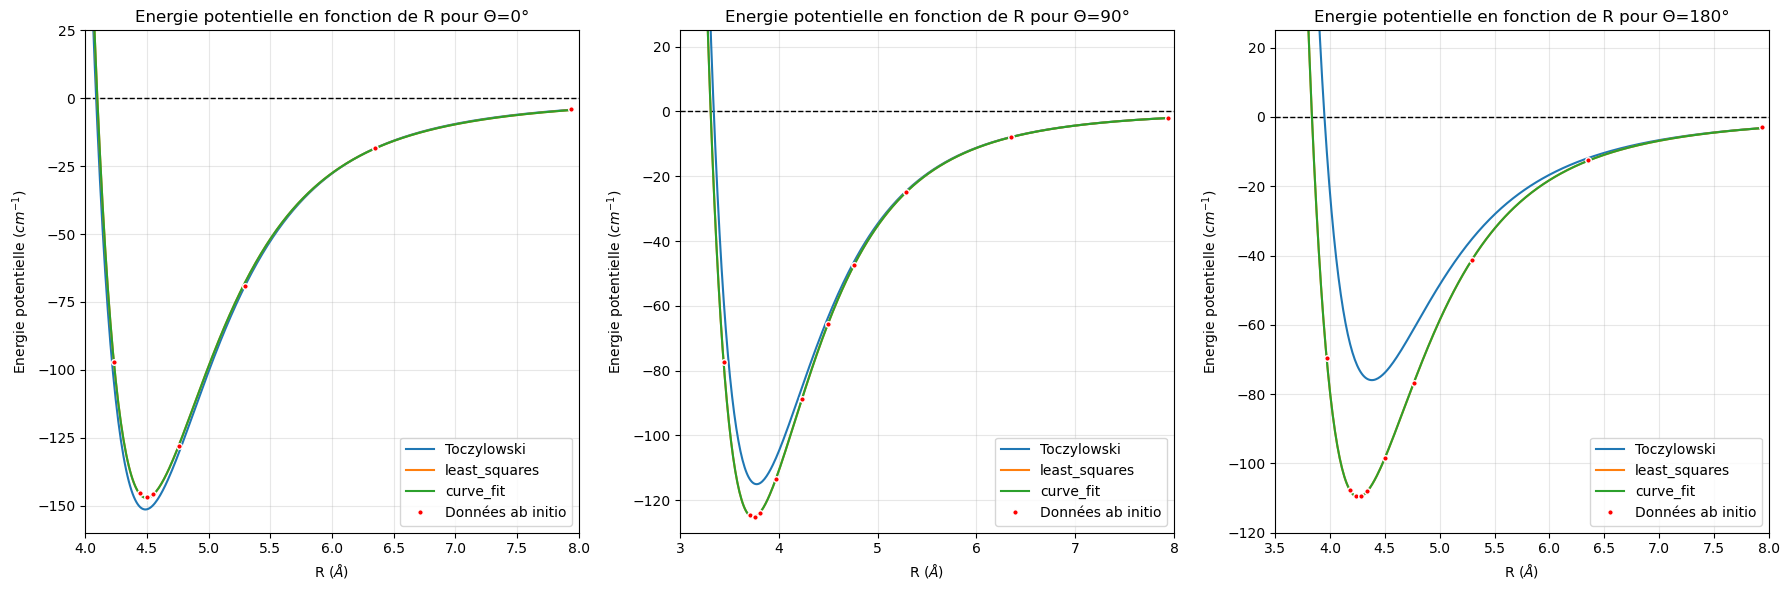

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_Theta_fix_zoom_cmm1(0, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[0], ylim=[-160,25], xlim=[4,8])
plot_Theta_fix_zoom_cmm1(9, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[1], ylim=[-130,25], xlim=[3,8])
plot_Theta_fix_zoom_cmm1(18, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[2], ylim=[-120,25], xlim=[3.5,8])

axes[0].legend()

plt.tight_layout()
plt.show()

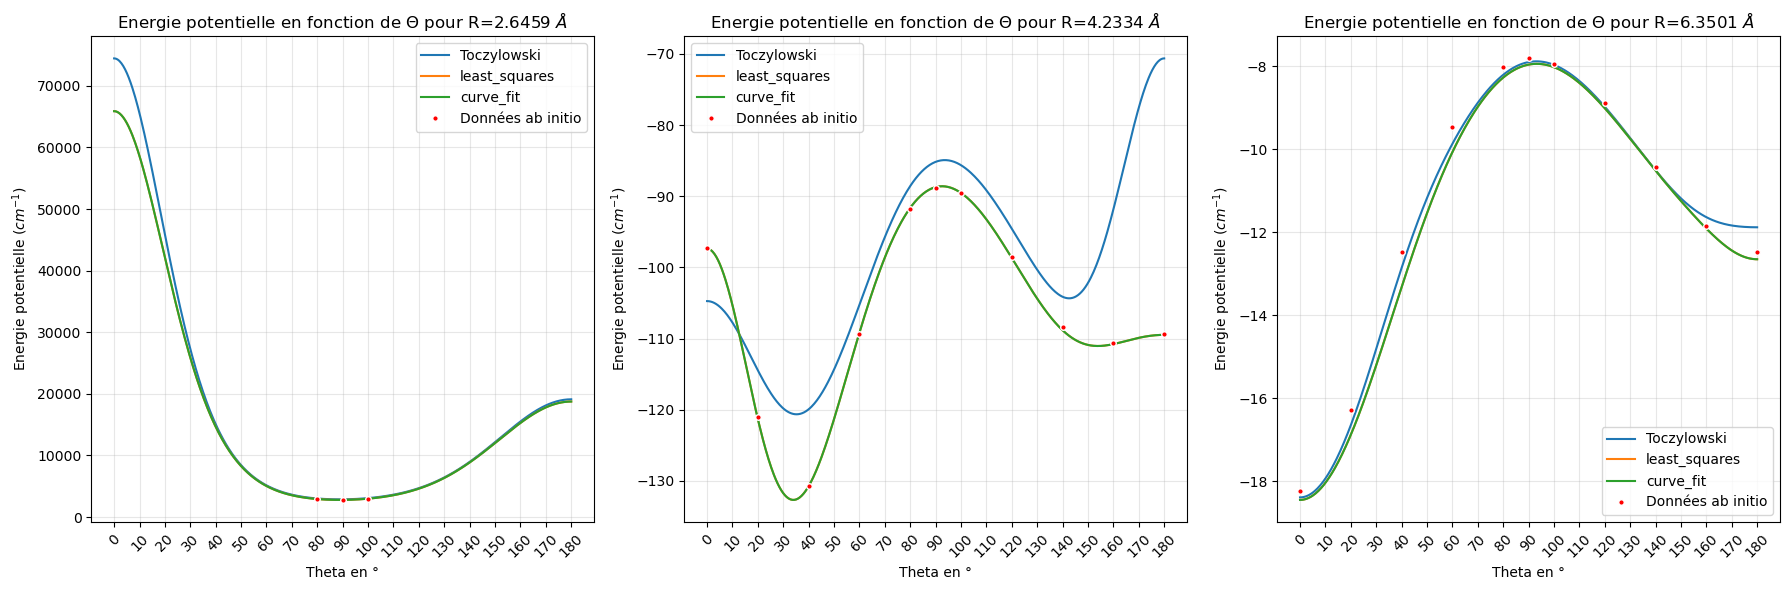

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_R_fix_cmm1(0, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[0])
plot_R_fix_cmm1(13, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[1])
plot_R_fix_cmm1(21, params, R_a0, Theta_deg, E_cmm1, V_opt, ax=axes[2])

axes[0].legend()

plt.tight_layout()
plt.show()

# Contour plot

In [46]:
def contour_plot(ax, params, title, inter=True, aff_Title=True):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([V_opt(params, np.full_like(theta_grid, r), theta_grid)for r in r_grid])
    
    # Niveaux
    levels_to_plot = np.array([-0.149, -0.189, -0.229, -0.269, -0.309, 
                               -0.349, -0.389, -0.429, -0.469, -0.489, -0.509, 
                               -0.549, -0.567, -0.568, -0.588, -0.629, -0.661])
    
    levels_with_labels = np.array([-0.229, -0.309, -0.389, -0.469, -0.509,
                                   -0.549, -0.567, -0.568, -0.629, -0.661])
    
    ##### CONTOURS INTERMEDIAIRES ####
    if inter:
        levels_inter = []
        for i in range(len(levels_to_plot) - 1):
            a, b = levels_to_plot[i], levels_to_plot[i + 1]
            inter = np.linspace(a, b, 6)
            levels_inter.extend(inter[1:-1])
        
        levels_inter = np.sort(np.unique(levels_inter))
    
        ax.contour(Theta_mesh, R_mesh, Z, levels=levels_inter, colors='gray', linewidths=0.7)
    
    #### CONTOURS PRINCIPAUX ####
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(Theta_mesh, R_mesh, Z,levels=[level],
                        colors='black',linewidths=1.2,linestyles='--')
        all_contours.append(cp)
    
    #### LABELS ####
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt=lambda x: f"{x * 219474.6313705 / 1000.0:.2f}", fontsize=10, inline=True)

    theta_dense = np.linspace(0, 180, 500)
    r_dense = np.linspace(6, 10, 500)
    
    r_min_courbe = []
    e_min_courbe = []
    for th in theta_dense:
        energies = V_opt(params, r_dense, np.full_like(r_dense, th))
    
        idx_min = np.argmin(energies)
    
        r_min_courbe.append(r_dense[idx_min])
        e_min_courbe.append(energies[idx_min])
    
    r_min_courbe = np.array(r_min_courbe)
    e_min_courbe = np.array(e_min_courbe)
    
    ax.plot(theta_dense,r_min_courbe,'-',color='red', linewidth=1, label='Courbe des minimums')

    
    theta_values = np.arange(0,181,20)
    r_dense = np.linspace(6,10,300) # Grille dense pour trouver le minimum avec précision

    #### Affichage des Min selon theta ####
    for th_val in theta_values:
        energies = V_opt(params, r_dense, np.full_like(r_dense,th_val))
        # Minimum
        min_idx = np.argmin(energies)
        min_E = energies[min_idx]
        min_r = r_dense[min_idx]
        
        # Affichage du point
        ax.plot(th_val, min_r, marker='o', color='red', markersize=5)
        
        # Affichage de la valeur
        ax.text(th_val, min_r + 0.08, f"{min_E * 219474.6313705 / 1000.0:.2f}",
                ha='center', va='bottom', fontsize=10, color='red',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
               )

    #### MISE EN PAGE #####
    if aff_Title:
        ax.set_title(f"Ar-HCN - Energie potentielle (cm⁻¹) - Pour θ=0 : Ar-HCN linéaire\n{title}", fontsize=16)
    
    ax.set_xlabel("Theta (°)", fontsize=15)
    xticks = np.arange(0, 181, 20)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=11)
    
    ax.set_ylabel(r"R ($\AA$)", fontsize=15)
    yticks = np.arange(6, 10.5, 0.5)
    ax.set_ylim(6,10)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{y*0.5291772109:.2f}" for y in yticks], fontsize=11)
    
    ax.set_box_aspect(1)  

    legende_point1 = Line2D([0], [0], linestyle='-', marker='o', color='red', ms=5, lw=1, label="Energie minimale")
    ax.legend(handles=[legende_point1],loc='upper right', fontsize=10, framealpha=0.9)

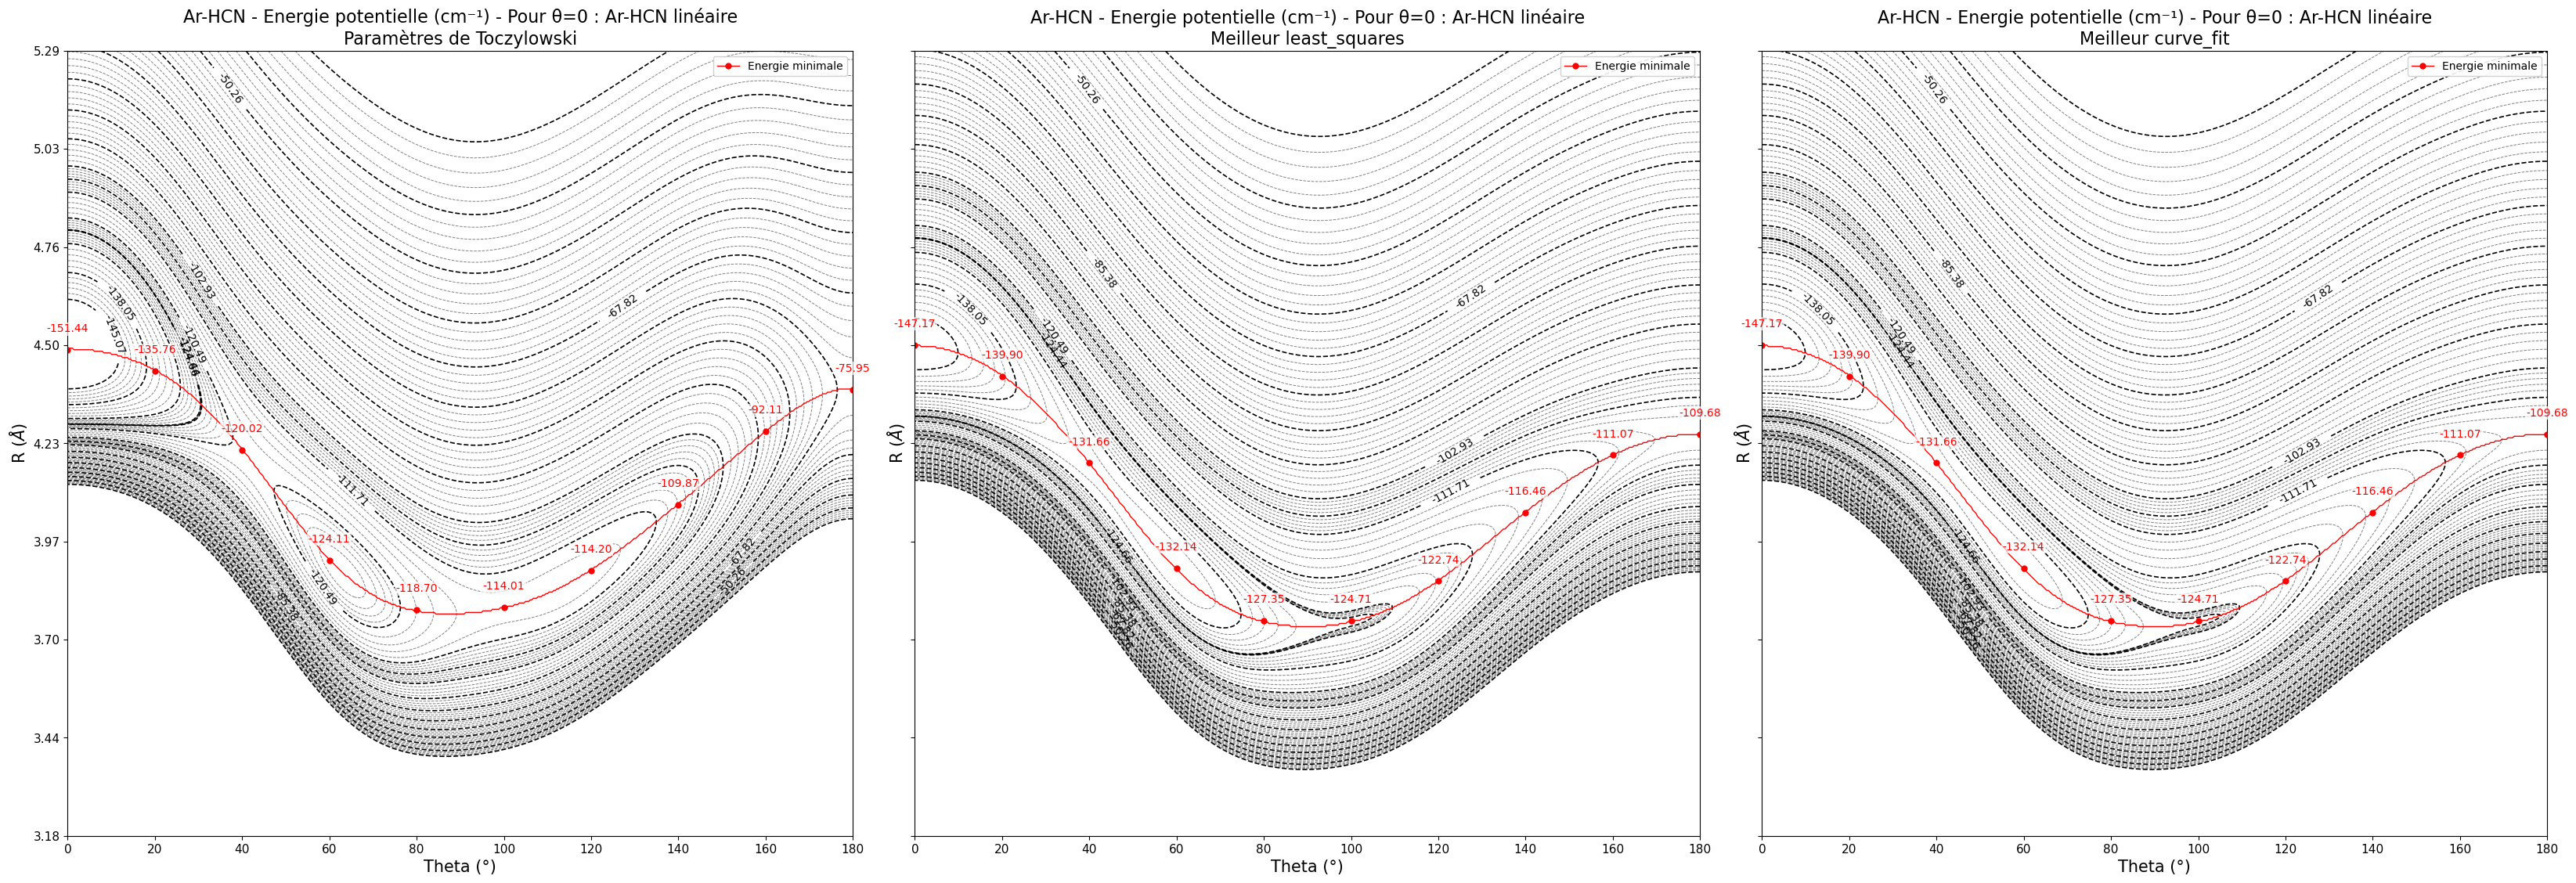

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(33, 11), sharey=True)

contour_plot(axes[0], params_toczylowski, "Paramètres de Toczylowski")
contour_plot(axes[1], params_ls_jac_soft, "Meilleur least_squares")
contour_plot(axes[2], params_cf, "Meilleur curve_fit")

plt.tight_layout()

## Erreur relative

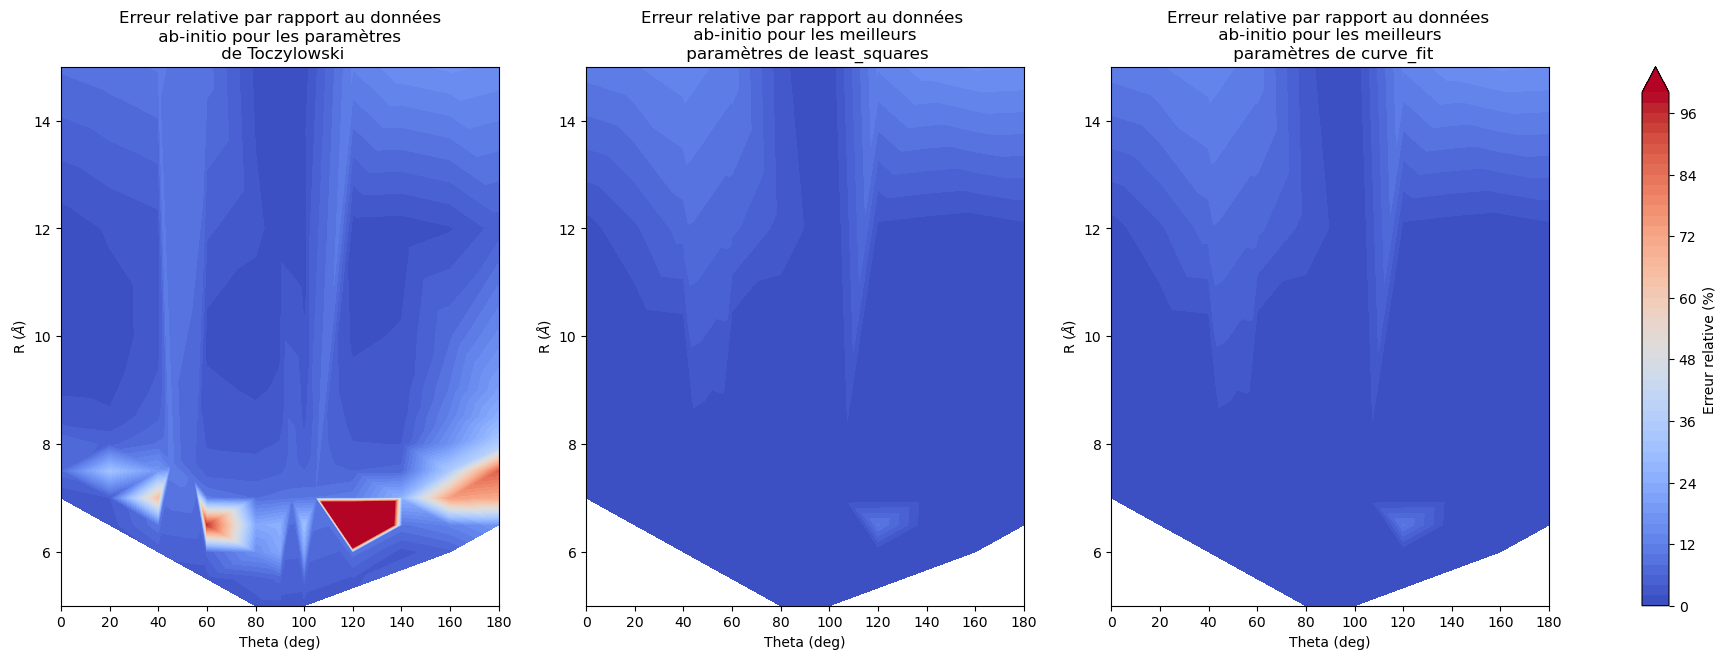

In [123]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

erreur_rel_tricontour(
    Theta_deg, R_a0, E_cmm1,
    {"Erreur relative par rapport au données\n ab-initio pour les paramètres \n de Toczylowski": params_toczylowski},
    V_opt,
    ax=axes[0]
)

erreur_rel_tricontour(
    Theta_deg, R_a0, E_cmm1,
    {"Erreur relative par rapport au données \n ab-initio pour les meilleurs \n paramètres de least_squares": params_ls_jac_soft},
    V_opt,
    ax=axes[1]
)

erreur_rel_tricontour(
    Theta_deg, R_a0, E_cmm1,
    {"Erreur relative par rapport au données \n ab-initio pour les meilleurs \n paramètres de curve_fit": params_cf},
    V_opt,
    ax=axes[2]
)

# colorbar unique (important)
fig.colorbar(
    axes[0].collections[0],
    ax=axes,
    orientation="vertical",
    label="Erreur relative (%)"
)


In [152]:
def erreur_rel_Theta_fix(theta_fix, Theta_deg, R_a0, E, params, V_opt,
                                axes, aff_Title=True):

    mask_theta = np.isclose(Theta_deg, theta_fix)

    R_plot = R_a0[mask_theta] * 0.529177210903
    E_plot = E[mask_theta]

    order = np.argsort(R_plot)
    R_plot = R_plot[order]
    E_plot = E_plot[order]

    for nom, p in params.items():

        V_fit = V_opt(p, R_a0, Theta_deg) * 219474.6313705 / 1000.0
        V_plot = V_fit[mask_theta][order]

        erreur = 100 * np.abs(V_plot - E_plot) / np.abs(E_plot)

        axes.plot(
            R_plot,
            erreur,
            marker='o',
            linestyle='-',
            label=nom
        )

    axes.set_xlabel(r"R ($\AA$)")
    axes.set_ylabel("Erreur relative (%)")

    if aff_Title:
        axes.set_title(f"Erreur relative par rapport aux données ab-initio \n\n θ = {theta_fix:.0f}°")

    axes.grid()
    axes.legend()
def erreur_abs_Theta_fix(theta_fix, Theta_deg, R_a0, E, params, V_opt,
                                axes, aff_Title=True):

    mask_theta = np.isclose(Theta_deg, theta_fix)

    R_plot = R_a0[mask_theta] * 0.529177210903
    E_plot = E[mask_theta]

    order = np.argsort(R_plot)
    R_plot = R_plot[order]
    E_plot = E_plot[order]

    for nom, p in params.items():

        V_fit = V_opt(p, R_a0, Theta_deg) * 219474.6313705 / 1000.0
        V_plot = V_fit[mask_theta][order]

        erreur = np.abs(V_plot - E_plot)

        axes.plot(
            R_plot,
            erreur,
            marker='o',
            linestyle='-',
            label=nom
        )

    axes.set_xlabel(r"R ($\AA$)")
    axes.set_ylabel("Erreur absolue (cm$^{-1}$)")

    if aff_Title:
        axes.set_title(f"Erreur absolue par rapport aux données ab-initio \n\n θ = {theta_fix:.0f}°")

    axes.grid()
    axes.legend()

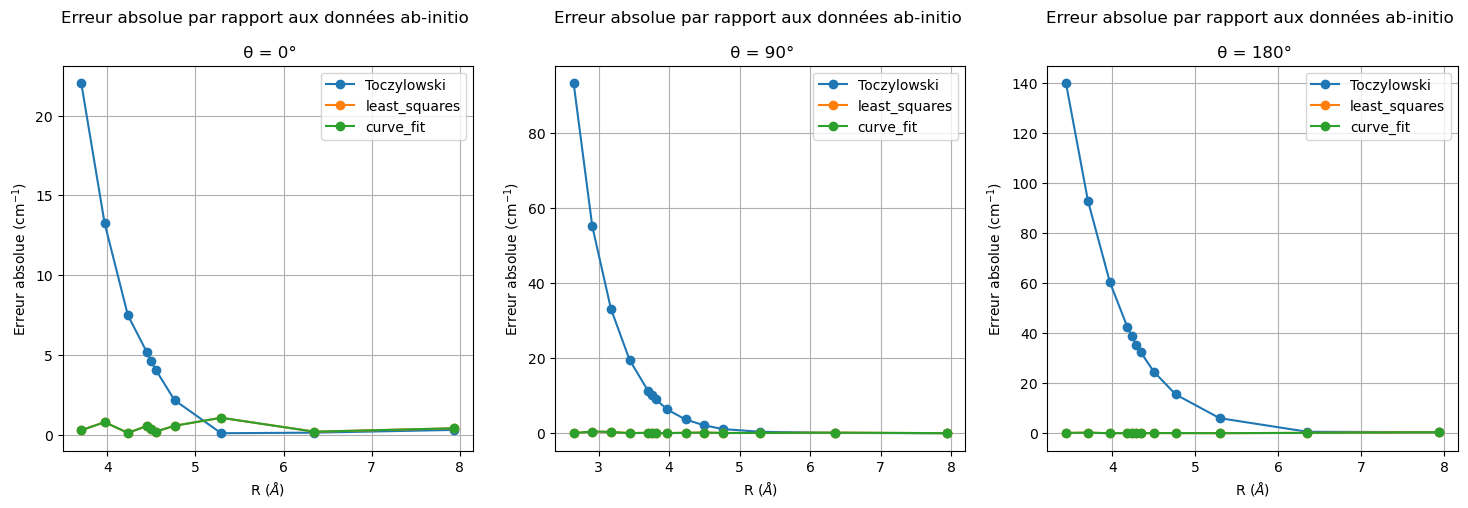

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
erreur_abs_Theta_fix(0,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[0])
erreur_abs_Theta_fix(90,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[1])
erreur_abs_Theta_fix(180,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[2])

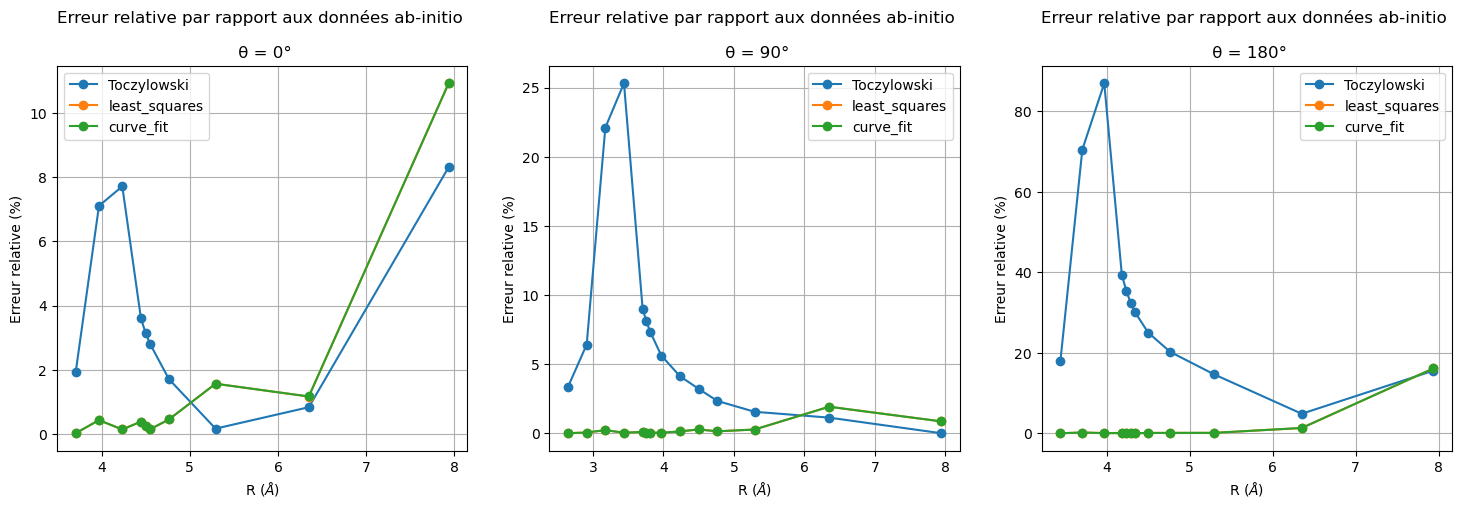

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

erreur_rel_Theta_fix(0,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[0])
erreur_rel_Theta_fix(90,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[1])
erreur_rel_Theta_fix(180,Theta_deg,R_a0,E_cmm1,params,V_opt,axes[2])

## Minimum Energy Path

In [43]:
def minimums(ax, params, title, uniteR="a0", uniteT="deg", uniteE="mEh", aff_Title=True):
    # Les grilles pour V_opt restent dans les unités d'origine
    theta_grid = np.linspace(0, 180, 500)
    r_dense = np.linspace(6, 10, 500)

    R_min_list = []
    E_min_list = []

    for theta_val in theta_grid:
        energies = V_opt(params, r_dense, np.full_like(r_dense, theta_val))
        
        # Extraction du minimum pour ce theta
        min_idx = np.argmin(energies)
        R_min_list.append(r_dense[min_idx])
        E_min_list.append(energies[min_idx])
        
    R_min_array = np.array(R_min_list)
    E_min_array = np.array(E_min_list)
    
    # Conversions
    if uniteE == "cmm1":
        E_min_array = E_min_array * 219474.6313705 / 1000.0
        
    if uniteR == "ang":
        R_min_array = R_min_array / 1.889726125
        
    # Gestion du cas d'inversion pour Theta
    if uniteT == "inv":
        theta_plot = 180 - theta_grid 
    else:
        theta_plot = theta_grid # Cas "deg" par défaut
        
    # Energie minimale
    line1 = ax.plot(theta_plot, E_min_array, color='crimson', linewidth=1.5, 
                    marker='.', markersize=3, label="Énergie min")
    if aff_Title:
        ax.set_title(f"Énergie et Distance minimales en fonction de Theta\nTheta = 0 pour Ar--HCN\n{title}", fontsize=16)
    ax.set_xlabel("Theta en °", fontsize=15)
    ax.set_ylabel(f"Énergie minimale ({uniteE})", color='crimson', fontsize=15)
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelcolor='crimson', labelsize=13)
    
    
    ax.grid(True, linestyle='--', alpha=0.5)

    # R correspondant
    ax2 = ax.twinx() 
    line2 = ax2.plot(theta_plot, R_min_array, color='teal', linewidth=1.5, 
                     marker='.', markersize=3, label="R min")
    if uniteR=="a0":                 
        ax2.set_ylabel("R correspondant (bohr)", color='teal', fontsize=15)
    elif uniteR=="ang":
        ax2.set_ylabel(r"R correspondant ($\AA$)", color='teal', fontsize=15)
    ax2.tick_params(axis='y', labelcolor='teal', labelsize=13)

    # Légende
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best')

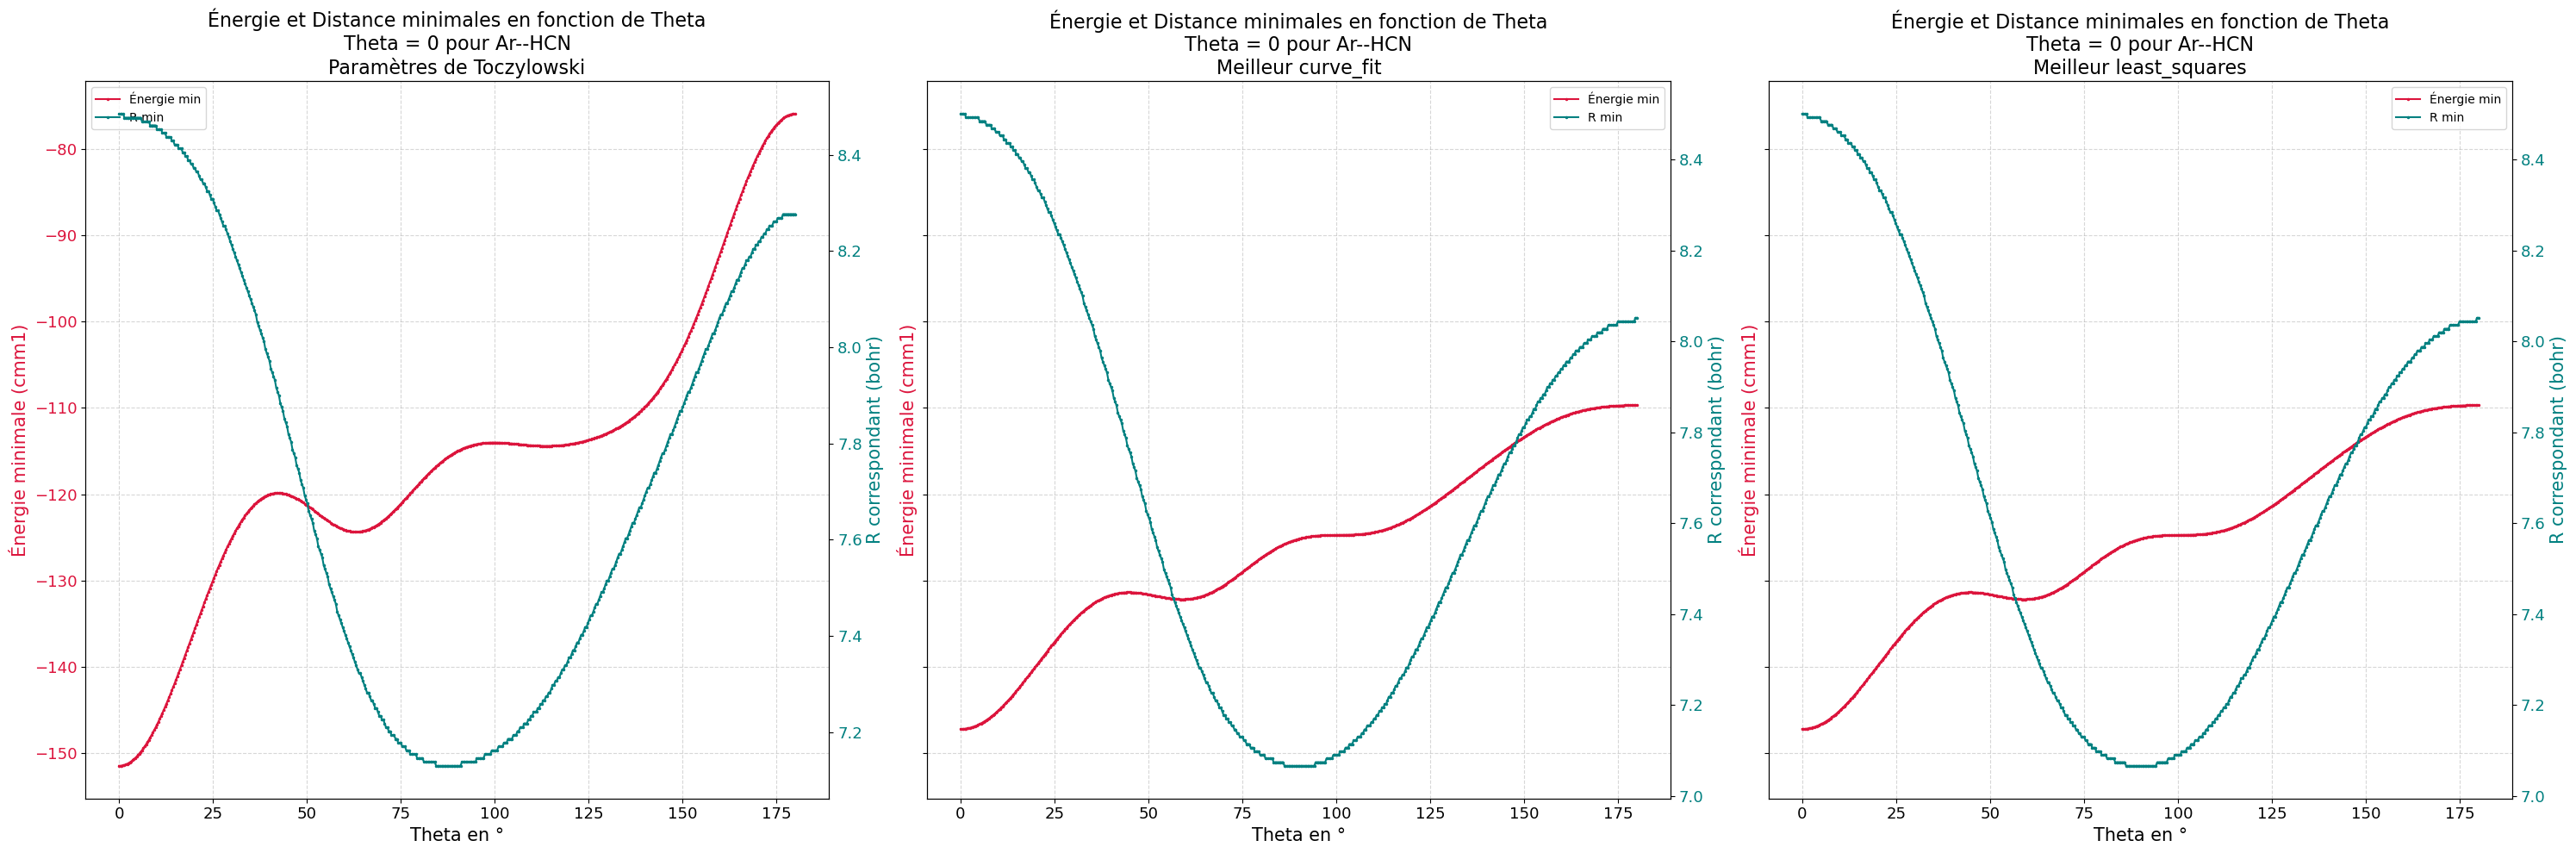

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10), sharey=True)

minimums(axes[0], params_toczylowski, "Paramètres de Toczylowski", uniteE="cmm1")
minimums(axes[1], params_ls_jac_soft, "Meilleur curve_fit", uniteE="cmm1")
minimums(axes[2], params_cf, "Meilleur least_squares", uniteE="cmm1")

plt.tight_layout()